# Incompressible Navier-Stokes 

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = -\frac{\partial p}{\partial x} + \nu \nabla^2 u$$

$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{\partial p}{\partial y} + \nu \nabla^2 v$$

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

**Where:**
- $u(t,x,y)$, $v(t,x,y)$ = velocity components in $x$ and $y$
- $p(t,x,y)$ = pressure field
- $-\frac{\partial p}{\partial x}$, $-\frac{\partial p}{\partial y}$ = pressure gradient forces — high pressure pushes fluid toward low pressure
- $\nu \nabla^2 u$, $\nu \nabla^2 v$ = viscous diffusion — internal friction resisting deformation
- $\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$ = the **incompressibility constraint** — fluid cannot be compressed or expanded;
whatever flows in must flow out

The **incompressible Navier-Stokes equations** are the culmination of everything built so far. They couple a vector velocity field $(u, v)$ to a pressure field $p$, with three equations that must all be satisfied simultaneously.

**Physical meaning:** This is real fluid dynamics. Every term has a job: inertia tries to keep the fluid moving, convection carries momentum with the flow, pressure gradients steer the fluid, and viscosity dissipates energy into heat. The incompressibility condition is what makes pressure non-trivial — it is not a dynamic variable but a *constraint enforcer* that adjusts itself at every instant to keep $\nabla \cdot \mathbf{u} = 0$.

**The leap from 2D Burgers to Navier-Stokes:** In 2D Burgers, you had two coupled velocity equations but no pressure and no incompressibility. Here, pressure enters as a third unknown that the PINN must simultaneously learn, and the divergence-free condition adds a fourth residual to the loss. The network now outputs **three quantities** at every point $(x, y, t)$: $u$, $v$, and $p$.

---

## This Problem Setup

**Domain:** $x \in [0, 2\pi]$, $y \in [0, 2\pi]$, $t \in [0, 2]$, $\nu = 0.1$

**Exact Solution — Taylor-Green Vortex:**

$$u(t,x,y) = -\cos(x)\sin(y)\,e^{-2\nu t}$$

$$v(t,x,y) = \sin(x)\cos(y)\,e^{-2\nu t}$$

$$p(t,x,y) = -\frac{1}{4}\bigl(\cos(2x) + \cos(2y)\bigr)\,e^{-4\nu t}$$

The Taylor-Green Vortex is one of the few known exact solutions to Navier-Stokes. It describes a periodic array of counter-rotating vortices that decay smoothly over time — viscosity dissipating the kinetic energy at rate $e^{-2\nu t}$. Pressure decays twice as fast at $e^{-4\nu t}$, a consequence of the quadratic relationship between pressure and velocity in incompressible flow.

**Initial & Boundary Conditions:**

All three fields $u$, $v$, $p$ are prescribed from the exact solution — both at $t=0$ and on all four boundary walls. The PINN must jointly satisfy the momentum equations, the incompressibility constraint, and match these prescribed values.

- **1000 initial condition points** randomly scattered over $(x,y) \in [0, 2\pi]^2$ at $t=0$
- **1000 boundary points** (250 per edge) randomly placed across all four walls for all times
- **8000 physics points** on a uniform $20 \times 20 \times 20$ grid enforcing all three PDE residuals in the interior

**Loss weights:** $w_\text{ic} = 1.0$, $w_\text{bc} = 10.0$, $w_\text{physics} = 1.0$ — boundary conditions are penalised more heavily to anchor the solution at the walls before the interior is shaped by physics.

In [3]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import optax
import copy

# ============ DOMAIN PARAMETERS ============
L = 2 * jnp.pi  # domain size [0, 2*pi] x [0, 2*pi]
T_final = 2.0    # time domain [0, T_final]
nu = 0.1     # diffusion coefficient

# Weights

w_ic = 1.0
w_bc = 10.0
w_physics = 1.0

"""
Incompressible Navier Stokes using TGV

u = -cos(x) * sin(y) * exp(-2*nu*t)
v = sin(x) * cos(y) * exp(-2*nu*t)
p = -0.25 * (cos(2*x) + cos(2*y)) * exp(-4*nu*t)

"""

def exact_solution(t, x, y, nu):
    u = -jnp.cos(x) * jnp.sin(y) * jnp.exp(-2 * nu * t)
    v = jnp.sin(x) * jnp.cos(y) * jnp.exp(-2 * nu * t)
    p = -0.25 * (jnp.cos(2 * x) + jnp.cos(2 * y)) * jnp.exp(-4 * nu * t)
    return u, v, p

# 1. Initial Condition points (1000 points at t=0)
key = random.PRNGKey(0)
N_ic = 1000

k1, k2 = random.split(key)

t_ic = jnp.zeros((N_ic, 1))  # t=0 for all IC points
x_ic = random.uniform(k1, (N_ic, 1), minval=0.0, maxval=L)
y_ic = random.uniform(k2, (N_ic, 1), minval=0.0, maxval=L)

u_ic, v_ic, p_ic = exact_solution(t_ic, x_ic, y_ic, nu)  # Get exact u, v, and p at t=0 for IC points

uvp_ic = jnp.concatenate([u_ic, v_ic, p_ic], axis=1)  # Shape (N_ic, 3)

# 2. Boundary Condition points (250 each side, total 1000 points). Use analytical solution to get u, v, and p at the boundary points, so we have exact BCs.

k3, k4, k5, k6, k7, k8, k9, k10 = random.split(k2, 8)
N_per_edge = 250

x_left = jnp.zeros((N_per_edge, 1))
y_left = random.uniform(k3, (N_per_edge, 1), minval=0.0, maxval=L)
t_left = random.uniform(k4, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_left, v_left, p_left = exact_solution(t_left, x_left, y_left, nu)

x_right = jnp.ones((N_per_edge, 1)) * L
y_right = random.uniform(k5, (N_per_edge, 1), minval=0.0, maxval=L)
t_right = random.uniform(k6, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_right, v_right, p_right = exact_solution(t_right, x_right, y_right, nu)

x_bottom = random.uniform(k7, (N_per_edge, 1), minval=0.0, maxval=L)
y_bottom = jnp.zeros((N_per_edge, 1))
t_bottom = random.uniform(k8, (N_per_edge, 1), minval=0.0, maxval=T_final)  

u_bottom, v_bottom, p_bottom = exact_solution(t_bottom, x_bottom, y_bottom, nu)

x_top = random.uniform(k9, (N_per_edge, 1), minval=0.0, maxval=L)
y_top = jnp.ones((N_per_edge, 1)) * L
t_top = random.uniform(k10, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_top, v_top, p_top = exact_solution(t_top, x_top, y_top, nu)

# Combine all boundary points
x_bc = jnp.concatenate([x_left, x_right, x_bottom, x_top])
y_bc = jnp.concatenate([y_left, y_right, y_bottom, y_top])
t_bc = jnp.concatenate([t_left, t_right, t_bottom, t_top])

u_bc = jnp.concatenate([u_left, u_right, u_bottom, u_top])
v_bc = jnp.concatenate([v_left, v_right, v_bottom, v_top])
p_bc = jnp.concatenate([p_left, p_right, p_bottom, p_top])
uvp_bc = jnp.concatenate([u_bc, v_bc, p_bc], axis=1)  # Shape (N_bc, 3)


# 3. Physics points (20*20*20 = 8000 points in the interior of the domain)
t_vals = jnp.linspace(0, T_final, 20)
x_vals = jnp.linspace(0, L, 20)
y_vals = jnp.linspace(0, L, 20)
t_grid, x_grid, y_grid = jnp.meshgrid(t_vals, x_vals, y_vals)  # Shape (20, 20, 20)
t_physics = t_grid.reshape(-1, 1)  # Shape (8000, 1)
x_physics = x_grid.reshape(-1, 1)  # Shape (8000, 1)
y_physics = y_grid.reshape(-1, 1)  # Shape (8000, 1)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g. [3, 128, 128, 128, 3]
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, y_point, nu):

    def u_v_p(t_val, x_val, y_val):
        txy_in = jnp.array([[t_val, x_val, y_val]])  # Shape (1, 3)
        return network(params, txy_in)[0]  # Shape (3,)
    
    jacobian_fn = jax.jacfwd(u_v_p, argnums=(0, 1, 2))  # Compute Jacobian w.r.t t, x, y
    J = jacobian_fn(t_point, x_point, y_point)  

    """J is a tuple of 3 vectors. First index = which input you differentiated with respect to. Second index = which output component.
        J[0] = ∂/∂t of [u, v, p] = [du/dt, dv/dt, dp/dt]
        J[1] = ∂/∂x of [u, v, p] = [du/dx, dv/dx, dp/dx]
        J[2] = ∂/∂y of [u, v, p] = [du/dy, dv/dy, dp/dy]
    """

    du_dt = J[0][0]  # du/dt
    dv_dt = J[0][1]  # dv/dt

    dp_dx = J[1][2]  # dp/dx
    dp_dy = J[2][2]  # dp/dy

    du_dx = J[1][0]  # du/dx
    du_dy = J[2][0]  # du/dy

    dv_dx = J[1][1]  # dv/dx
    dv_dy = J[2][1]  # dv/dy

    # Only ∂²/∂x² of all three outputs — one call
    H_xx = jax.jacfwd(jax.jacfwd(u_v_p, argnums=1), argnums=1)
    H_xx_vals = H_xx(t_point, x_point, y_point)  # compute once and reuse for both u and v

    # Only ∂²/∂y² of all three outputs — one call  
    H_yy = jax.jacfwd(jax.jacfwd(u_v_p, argnums=2), argnums=2)
    H_yy_vals = H_yy(t_point, x_point, y_point)  # compute once and reuse for both u and v

    d2u_dx2 = H_xx_vals[0]  # ∂²u/∂x²
    d2u_dy2 = H_yy_vals[0]  # ∂²u/∂y²

    d2v_dx2 = H_xx_vals[1]  # ∂²v/∂x²
    d2v_dy2 = H_yy_vals[1]  # ∂²v/∂y²


    uvp_vals = u_v_p(t_point, x_point, y_point)
    u_ = uvp_vals[0]
    v_ = uvp_vals[1]

    residual_u = du_dt + u_ * du_dx + v_ * du_dy - nu * (d2u_dx2 + d2u_dy2) + dp_dx
    residual_v = dv_dt + u_ * dv_dx + v_ * dv_dy - nu * (d2v_dx2 + d2v_dy2) + dp_dy
    residual_incompressibility = du_dx + dv_dy  # Should be zero for incompressible flow

    return residual_u, residual_v, residual_incompressibility


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 900 times, once for each (t, x, y) triple, keeping params and nu fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [3, 128, 128, 128, 3]  # 3 inputs (t, x, y), 3 outputs (u, v, p)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=40000, alpha=1e-5)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state, t_ic, x_ic, y_ic, uvp_ic, 
                t_bc, x_bc, y_bc, uvp_bc, t_physics, x_physics, y_physics, nu):

    def loss_fn(params):

        # 1. Initial Condition Loss
        # Network prediction at IC points
        txy_ic = jnp.concatenate([t_ic, x_ic, y_ic], axis=1)  # Combine t, x, and y
        uvp_pred_ic = network(params, txy_ic)
        ic_loss = jnp.mean((uvp_pred_ic - uvp_ic)**2)
        
        # # 2. Boundary Condition Loss
        txy_bc = jnp.concatenate([t_bc, x_bc, y_bc], axis=1)
        uvp_pred_bc = network(params, txy_bc)
        bc_loss = jnp.mean((uvp_pred_bc - uvp_bc)**2)
        
        # 3. Physics Loss
        physics_residual_u, physics_residual_v, physics_residual_p = physics_residual_batch(params, 
                                                t_physics.ravel(), 
                                                x_physics.ravel(), 
                                                y_physics.ravel(), 
                                                nu)

        physics_loss = jnp.mean(physics_residual_u**2 + physics_residual_v**2 + physics_residual_p**2) 

        # return total loss plus a tuple of the individual components as auxiliary data
        return w_ic * ic_loss + w_bc * bc_loss + w_physics * physics_loss, (ic_loss, bc_loss, physics_loss)
    
        # Compute loss and gradients; use has_aux=True so we can extract the individual losses
    (loss_val, indivicual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, indivicual_loss


# Training parameters
num_iterations = 40000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()
y_phys_flat = y_physics.ravel()

# Training loop
losses = []
losses_ic = []
losses_bc = []
losses_physics = []
for i in range(num_iterations):
    params, opt_state, loss, individual_losses = update_step(
        params, opt_state,
        t_ic, x_ic, y_ic, uvp_ic,
        t_bc, x_bc, y_bc, uvp_bc,
        t_phys_flat, x_phys_flat, y_phys_flat,
        nu
    )
    
    losses.append(loss)
    losses_ic.append(individual_losses[0])
    losses_bc.append(individual_losses[1])
    losses_physics.append(individual_losses[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    # Print progress every 1000 iterations
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  IC Loss: {individual_losses[0]:.6f}, BC Loss: {individual_losses[1]:.6f}, Physics Loss: {individual_losses[2]:.6f}")


Iteration 1000/40000, Loss: 0.196641
  IC Loss: 0.070645, BC Loss: 0.008264, Physics Loss: 0.043361
Iteration 2000/40000, Loss: 0.083380
  IC Loss: 0.026021, BC Loss: 0.003347, Physics Loss: 0.023890
Iteration 3000/40000, Loss: 0.029488
  IC Loss: 0.005942, BC Loss: 0.000928, Physics Loss: 0.014265
Iteration 4000/40000, Loss: 0.011204
  IC Loss: 0.001287, BC Loss: 0.000428, Physics Loss: 0.005635
Iteration 5000/40000, Loss: 0.004166
  IC Loss: 0.000379, BC Loss: 0.000167, Physics Loss: 0.002117
Iteration 6000/40000, Loss: 0.001612
  IC Loss: 0.000130, BC Loss: 0.000050, Physics Loss: 0.000984
Iteration 7000/40000, Loss: 0.001336
  IC Loss: 0.000100, BC Loss: 0.000058, Physics Loss: 0.000651
Iteration 8000/40000, Loss: 0.001480
  IC Loss: 0.000114, BC Loss: 0.000085, Physics Loss: 0.000516
Iteration 9000/40000, Loss: 0.001889
  IC Loss: 0.000144, BC Loss: 0.000130, Physics Loss: 0.000444
Iteration 10000/40000, Loss: 0.000767
  IC Loss: 0.000056, BC Loss: 0.000043, Physics Loss: 0.000281

## Validation Plots

    t |    u err % |    v err % |    p err %
-----------------------------------------------------------------
  0.0 |     0.376% |     0.371% |     0.607%
  0.5 |     0.234% |     0.269% |     0.626%
  1.0 |     0.232% |     0.242% |     0.824%
  1.5 |     0.242% |     0.249% |     0.729%


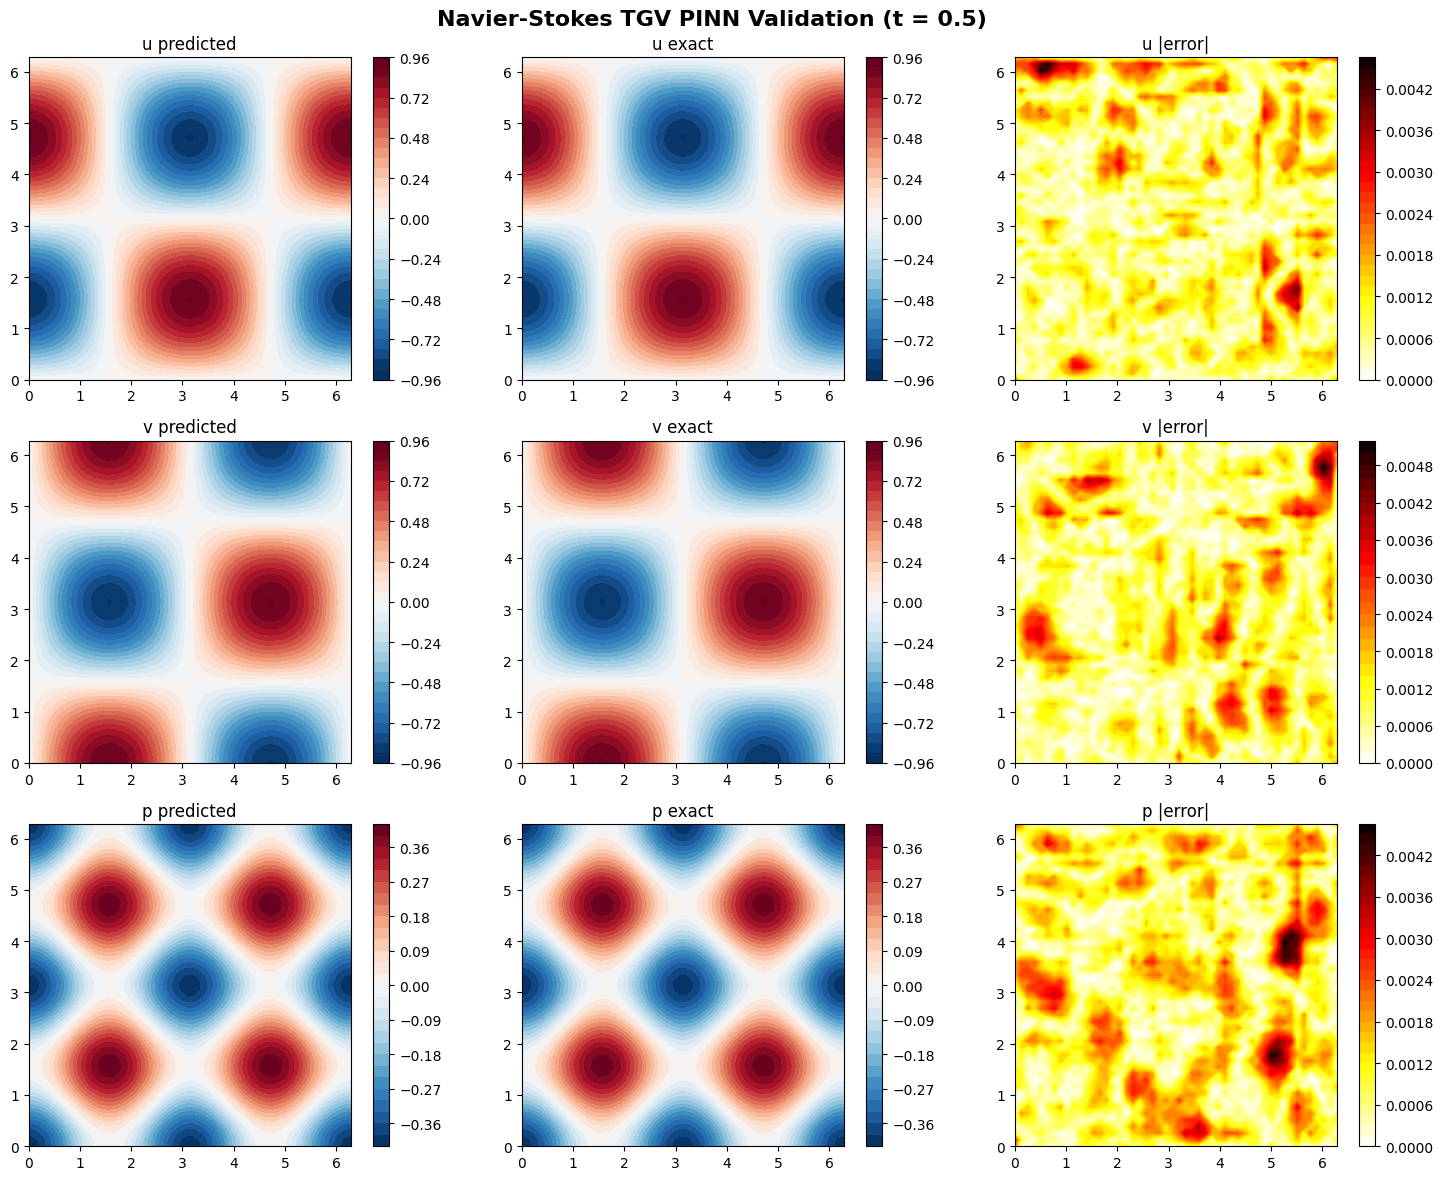

Saved: ns_tgv_validation.png


In [6]:
"""
Validation script for Navier-Stokes TGV PINN
Run this AFTER training. Assumes: params, network, exact_solution, L, nu are defined.
"""
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ============ 1. QUANTITATIVE VALIDATION: Relative L2 errors ============

N_test = 50
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)  # (2500, 1)
yy_flat = yy.reshape(-1, 1)  # (2500, 1)

time_slices = [0.0, 0.5, 1.0, 1.5]

print("=" * 65)
print(f"{'t':>5} | {'u err %':>10} | {'v err %':>10} | {'p err %':>10}")
print("-" * 65)

for t_val in time_slices:
    tt_flat = jnp.ones_like(xx_flat) * t_val
    
    # Network prediction
    txy_test = jnp.concatenate([tt_flat, xx_flat, yy_flat], axis=1)  # (2500, 3)
    uvp_pred = network(params, txy_test)  # (2500, 3)
    
    u_pred = uvp_pred[:, 0]
    v_pred = uvp_pred[:, 1]
    p_pred = uvp_pred[:, 2]
    
    # Exact solution
    u_exact, v_exact, p_exact = exact_solution(tt_flat, xx_flat, yy_flat, nu)
    u_exact = u_exact.ravel()
    v_exact = v_exact.ravel()
    p_exact = p_exact.ravel()
    
    # Relative L2 errors: ||pred - exact|| / ||exact||
    u_err = jnp.linalg.norm(u_pred - u_exact) / jnp.linalg.norm(u_exact) * 100
    v_err = jnp.linalg.norm(v_pred - v_exact) / jnp.linalg.norm(v_exact) * 100
    p_err = jnp.linalg.norm(p_pred - p_exact) / jnp.linalg.norm(p_exact) * 100
    
    print(f"{t_val:>5.1f} | {u_err:>9.3f}% | {v_err:>9.3f}% | {p_err:>9.3f}%")

print("=" * 65)


# ============ 2. VISUAL VALIDATION: Predicted vs Exact at t=0.5 ============

t_plot = 0.5
tt_plot = jnp.ones_like(xx_flat) * t_plot

txy_plot = jnp.concatenate([tt_plot, xx_flat, yy_flat], axis=1)
uvp_plot = network(params, txy_plot)

u_exact_plot, v_exact_plot, p_exact_plot = exact_solution(tt_plot, xx_flat, yy_flat, nu)

fields = {
    'u': (uvp_plot[:, 0], u_exact_plot.ravel()),
    'v': (uvp_plot[:, 1], v_exact_plot.ravel()),
    'p': (uvp_plot[:, 2], p_exact_plot.ravel()),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'Navier-Stokes TGV PINN Validation (t = {t_plot})', fontsize=16, fontweight='bold')

for row, (name, (pred, exact)) in enumerate(fields.items()):
    pred_2d = pred.reshape(N_test, N_test)
    exact_2d = exact.reshape(N_test, N_test)
    error_2d = jnp.abs(pred_2d - exact_2d)
    
    # Shared color limits for pred vs exact
    vmin = min(float(pred_2d.min()), float(exact_2d.min()))
    vmax = max(float(pred_2d.max()), float(exact_2d.max()))
    
    # Predicted
    im0 = axes[row, 0].contourf(xx, yy, pred_2d, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f'{name} predicted')
    axes[row, 0].set_aspect('equal')
    plt.colorbar(im0, ax=axes[row, 0])
    
    # Exact
    im1 = axes[row, 1].contourf(xx, yy, exact_2d, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f'{name} exact')
    axes[row, 1].set_aspect('equal')
    plt.colorbar(im1, ax=axes[row, 1])
    
    # Absolute error
    im2 = axes[row, 2].contourf(xx, yy, error_2d, levels=30, cmap='hot_r')
    axes[row, 2].set_title(f'{name} |error|')
    axes[row, 2].set_aspect('equal')
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.savefig('ns_tgv_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_validation.png")


# # ============ 3. LOSS CURVES ============
# # Assumes losses, losses_ic, losses_bc, losses_physics are defined from training

# fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Total loss (log scale)
# ax1.semilogy(losses)
# ax1.set_xlabel('Iteration')
# ax1.set_ylabel('Total Loss')
# ax1.set_title('Total Loss')
# ax1.grid(True, alpha=0.3)

# # Individual losses (log scale)
# ax2.semilogy(losses_ic, label='IC', alpha=0.8)
# ax2.semilogy(losses_bc, label='BC', alpha=0.8)
# ax2.semilogy(losses_physics, label='Physics', alpha=0.8)
# ax2.set_xlabel('Iteration')
# ax2.set_ylabel('Loss')
# ax2.set_title('Individual Losses')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('ns_tgv_losses.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved: ns_tgv_losses.png")

## Visuals

In [2]:
"""
Animated GIF for Navier-Stokes TGV PINN
Shows predicted vs exact fields evolving over time.
Run AFTER training. Assumes: params, network, exact_solution, L, nu are defined.
"""
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax.numpy as jnp
import numpy as np

# ============ Setup test grid ============
N_test = 60
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)
yy_flat = yy.reshape(-1, 1)

# Time frames for animation
n_frames = 60
t_frames = jnp.linspace(0, T_final, n_frames)

# ============ Precompute all frames ============
print("Precomputing frames...")
all_pred = []
all_exact = []

for i, t_val in enumerate(t_frames):
    tt_flat = jnp.ones_like(xx_flat) * t_val
    txy_test = jnp.concatenate([tt_flat, xx_flat, yy_flat], axis=1)
    
    # Predictions
    uvp_pred = network(params, txy_test)
    u_pred = np.array(uvp_pred[:, 0].reshape(N_test, N_test))
    v_pred = np.array(uvp_pred[:, 1].reshape(N_test, N_test))
    p_pred = np.array(uvp_pred[:, 2].reshape(N_test, N_test))
    
    # Exact
    u_ex, v_ex, p_ex = exact_solution(tt_flat, xx_flat, yy_flat, nu)
    u_ex = np.array(u_ex.ravel().reshape(N_test, N_test))
    v_ex = np.array(v_ex.ravel().reshape(N_test, N_test))
    p_ex = np.array(p_ex.ravel().reshape(N_test, N_test))
    
    all_pred.append((u_pred, v_pred, p_pred))
    all_exact.append((u_ex, v_ex, p_ex))
    
    if (i + 1) % 20 == 0:
        print(f"  Frame {i+1}/{n_frames}")

xx_np = np.array(xx)
yy_np = np.array(yy)

# ============ GIF 1: All three fields predicted vs exact ============
print("Generating field comparison GIF...")

fig1, axes1 = plt.subplots(2, 3, figsize=(15, 9))
fig1.subplots_adjust(hspace=0.3, wspace=0.35)

# Global color limits (from t=0, when amplitude is largest)
u_lim = max(abs(all_exact[0][0].min()), abs(all_exact[0][0].max()))
v_lim = max(abs(all_exact[0][1].min()), abs(all_exact[0][1].max()))
p_lim = max(abs(all_exact[0][2].min()), abs(all_exact[0][2].max()))

field_names = ['u (x-velocity)', 'v (y-velocity)', 'p (pressure)']
lims = [u_lim, v_lim, p_lim]

def animate_fields(frame):
    for ax_row in axes1:
        for ax in ax_row:
            ax.clear()
    
    t_val = float(t_frames[frame])
    fig1.suptitle(f'Navier-Stokes TGV  |  t = {t_val:.3f}  |  ν = {nu}', 
                  fontsize=16, fontweight='bold', y=0.98)
    
    for col in range(3):
        pred_field = all_pred[frame][col]
        exact_field = all_exact[frame][col]
        lim = lims[col]
        
        # Top row: Predicted
        im0 = axes1[0, col].contourf(xx_np, yy_np, pred_field, levels=30, 
                                      cmap='RdBu_r', vmin=-lim, vmax=lim)
        axes1[0, col].set_title(f'{field_names[col]} — PINN', fontsize=11)
        axes1[0, col].set_aspect('equal')
        axes1[0, col].set_xlim(0, float(L))
        axes1[0, col].set_ylim(0, float(L))
        
        # Bottom row: Exact
        im1 = axes1[1, col].contourf(xx_np, yy_np, exact_field, levels=30, 
                                      cmap='RdBu_r', vmin=-lim, vmax=lim)
        axes1[1, col].set_title(f'{field_names[col]} — Exact', fontsize=11)
        axes1[1, col].set_aspect('equal')
        axes1[1, col].set_xlim(0, float(L))
        axes1[1, col].set_ylim(0, float(L))
    
    # Row labels
    axes1[0, 0].set_ylabel('PINN Prediction', fontsize=12, fontweight='bold')
    axes1[1, 0].set_ylabel('Exact Solution', fontsize=12, fontweight='bold')
    
    return []

ani1 = animation.FuncAnimation(fig1, animate_fields, frames=n_frames, interval=80, blit=False)
ani1.save('ns_tgv_fields.gif', writer='pillow', fps=12, dpi=100)
print("Saved: ns_tgv_fields.gif")
plt.close(fig1)


# ============ GIF 2: Velocity magnitude + streamlines ============
print("Generating velocity streamline GIF...")

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# Subsample grid for streamlines
skip = 3
xs = xx_np[::skip, ::skip]
ys = yy_np[::skip, ::skip]

def animate_streamlines(frame):
    for ax in axes2:
        ax.clear()
    
    t_val = float(t_frames[frame])
    fig2.suptitle(f'Velocity Field  |  t = {t_val:.3f}  |  ν = {nu}', 
                  fontsize=14, fontweight='bold')
    
    for idx, (label, data) in enumerate([('PINN', all_pred), ('Exact', all_exact)]):
        u_field = data[frame][0]
        v_field = data[frame][1]
        speed = np.sqrt(u_field**2 + v_field**2)
        
        # Velocity magnitude as background
        im = axes2[idx].contourf(xx_np, yy_np, speed, levels=30, cmap='viridis', 
                                  vmin=0, vmax=1.0)
        
        # Streamlines on top
        axes2[idx].streamplot(xx_np, yy_np, u_field, v_field, 
                               color='white', linewidth=0.6, density=1.5, 
                               arrowsize=0.8, arrowstyle='->')
        
        axes2[idx].set_title(f'{label}', fontsize=12)
        axes2[idx].set_aspect('equal')
        axes2[idx].set_xlim(0, float(L))
        axes2[idx].set_ylim(0, float(L))
    
    return []

ani2 = animation.FuncAnimation(fig2, animate_streamlines, frames=n_frames, interval=80, blit=False)
ani2.save('ns_tgv_streamlines.gif', writer='pillow', fps=12, dpi=100)
print("Saved: ns_tgv_streamlines.gif")
plt.close(fig2)


# ============ GIF 3: Pressure with velocity arrows (quiver) ============
print("Generating pressure + quiver GIF...")

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

skip_q = 4
xq = xx_np[::skip_q, ::skip_q]
yq = yy_np[::skip_q, ::skip_q]

def animate_pressure(frame):
    for ax in axes3:
        ax.clear()
    
    t_val = float(t_frames[frame])
    fig3.suptitle(f'Pressure + Velocity Vectors  |  t = {t_val:.3f}', 
                  fontsize=14, fontweight='bold')
    
    for idx, (label, data) in enumerate([('PINN', all_pred), ('Exact', all_exact)]):
        p_field = data[frame][2]
        u_field = data[frame][0]
        v_field = data[frame][1]
        
        # Pressure contour
        im = axes3[idx].contourf(xx_np, yy_np, p_field, levels=30, cmap='RdBu_r',
                                  vmin=-p_lim, vmax=p_lim)
        
        # Velocity quiver arrows (subsampled)
        uq = u_field[::skip_q, ::skip_q]
        vq = v_field[::skip_q, ::skip_q]
        axes3[idx].quiver(xq, yq, uq, vq, color='black', alpha=0.6, scale=15)
        
        axes3[idx].set_title(f'{label}', fontsize=12)
        axes3[idx].set_aspect('equal')
        axes3[idx].set_xlim(0, float(L))
        axes3[idx].set_ylim(0, float(L))
    
    return []

ani3 = animation.FuncAnimation(fig3, animate_pressure, frames=n_frames, interval=80, blit=False)
ani3.save('ns_tgv_pressure.gif', writer='pillow', fps=12, dpi=100)
print("Saved: ns_tgv_pressure.gif")
plt.close(fig3)

print("\nDone! Three GIFs generated:")
print("  1. ns_tgv_fields.gif      — All fields side by side")
print("  2. ns_tgv_streamlines.gif  — Velocity magnitude + streamlines") 
print("  3. ns_tgv_pressure.gif     — Pressure field + velocity arrows")

Precomputing frames...
  Frame 20/60
  Frame 40/60
  Frame 60/60
Generating field comparison GIF...
Saved: ns_tgv_fields.gif
Generating velocity streamline GIF...
Saved: ns_tgv_streamlines.gif
Generating pressure + quiver GIF...
Saved: ns_tgv_pressure.gif

Done! Three GIFs generated:
  1. ns_tgv_fields.gif      — All fields side by side
  2. ns_tgv_streamlines.gif  — Velocity magnitude + streamlines
  3. ns_tgv_pressure.gif     — Pressure field + velocity arrows


## More Visuals

In [7]:
"""
3D Animated GIFs for Navier-Stokes TGV PINN
Creates visually striking 3D rotating surface plots for social media.
Run AFTER training. Assumes: params, network, exact_solution, L, T_final, nu are defined.
"""
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import jax.numpy as jnp
import numpy as np
from matplotlib import cm

# ============ Setup test grid ============
N_test = 80  # Higher resolution for smooth surfaces
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)
yy_flat = yy.reshape(-1, 1)
xx_np = np.array(xx)
yy_np = np.array(yy)


# ============ GIF 1: Rotating 3D pressure surface at t=0 ============
print("Generating rotating 3D pressure surface...")

t_val = 0.0
tt_flat = jnp.ones_like(xx_flat) * t_val
txy_test = jnp.concatenate([tt_flat, xx_flat, yy_flat], axis=1)
uvp_pred = network(params, txy_test)

p_pred_2d = np.array(uvp_pred[:, 2].reshape(N_test, N_test))
u_pred_2d = np.array(uvp_pred[:, 0].reshape(N_test, N_test))
v_pred_2d = np.array(uvp_pred[:, 1].reshape(N_test, N_test))
speed_2d = np.sqrt(u_pred_2d**2 + v_pred_2d**2)

fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

def animate_rotate_pressure(frame):
    ax1.clear()
    
    # Pressure as height, velocity magnitude as color
    surf = ax1.plot_surface(xx_np, yy_np, p_pred_2d, 
                            facecolors=cm.viridis(speed_2d / speed_2d.max()),
                            rstride=1, cstride=1, antialiased=True, shade=True)
    
    ax1.set_xlabel('x', fontsize=12, labelpad=8)
    ax1.set_ylabel('y', fontsize=12, labelpad=8)
    ax1.set_zlabel('Pressure', fontsize=12, labelpad=8)
    ax1.set_title('PINN: Pressure Surface colored by |velocity|\nt = 0.0', 
                  fontsize=14, fontweight='bold', pad=15)
    
    ax1.set_zlim(-0.55, 0.55)
    ax1.view_init(elev=25, azim=frame * 3)  # Rotate 3 degrees per frame
    
    return []

ani1 = animation.FuncAnimation(fig1, animate_rotate_pressure, frames=120, interval=50, blit=False)
ani1.save('ns_3d_pressure_rotate.gif', writer='pillow', fps=20, dpi=120)
print("Saved: ns_3d_pressure_rotate.gif")
plt.close(fig1)


# ============ GIF 2: 3D surface evolving in time (pressure decaying) ============
print("Generating 3D pressure time evolution...")

n_time_frames = 60
t_anim = np.linspace(0, float(T_final), n_time_frames)

# Precompute all frames
print("  Precomputing frames...")
p_frames = []
speed_frames = []
for i, tv in enumerate(t_anim):
    tt = jnp.ones_like(xx_flat) * tv
    txy = jnp.concatenate([tt, xx_flat, yy_flat], axis=1)
    uvp = network(params, txy)
    p_frames.append(np.array(uvp[:, 2].reshape(N_test, N_test)))
    u_f = np.array(uvp[:, 0].reshape(N_test, N_test))
    v_f = np.array(uvp[:, 1].reshape(N_test, N_test))
    speed_frames.append(np.sqrt(u_f**2 + v_f**2))

# Global limits
p_max = max(np.abs(pf).max() for pf in p_frames)
speed_max = max(sf.max() for sf in speed_frames)

fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

def animate_time_evolution(frame):
    ax2.clear()
    
    p_field = p_frames[frame]
    speed_field = speed_frames[frame]
    colors = cm.coolwarm((p_field + p_max) / (2 * p_max))  # Color by pressure value
    
    surf = ax2.plot_surface(xx_np, yy_np, p_field,
                            facecolors=colors,
                            rstride=1, cstride=1, antialiased=True, shade=True)
    
    ax2.set_xlabel('x', fontsize=12, labelpad=8)
    ax2.set_ylabel('y', fontsize=12, labelpad=8)
    ax2.set_zlabel('Pressure', fontsize=12, labelpad=8)
    ax2.set_title(f'PINN: Pressure Field Decaying\nt = {t_anim[frame]:.2f}  |  ν = {nu}', 
                  fontsize=14, fontweight='bold', pad=15)
    
    ax2.set_zlim(-p_max * 1.1, p_max * 1.1)
    ax2.view_init(elev=30, azim=45 + frame * 1.5)  # Slow rotation while evolving
    
    return []

ani2 = animation.FuncAnimation(fig2, animate_time_evolution, frames=n_time_frames, interval=80, blit=False)
ani2.save('ns_3d_pressure_decay.gif', writer='pillow', fps=15, dpi=120)
print("Saved: ns_3d_pressure_decay.gif")
plt.close(fig2)


# ============ GIF 3: Velocity magnitude surface with streamlines projected below ============
print("Generating 3D velocity surface with floor streamlines...")

fig3 = plt.figure(figsize=(12, 9))
ax3 = fig3.add_subplot(111, projection='3d')

# Precompute velocity data
u_frames = []
v_frames = []
for i, tv in enumerate(t_anim):
    tt = jnp.ones_like(xx_flat) * tv
    txy = jnp.concatenate([tt, xx_flat, yy_flat], axis=1)
    uvp = network(params, txy)
    u_frames.append(np.array(uvp[:, 0].reshape(N_test, N_test)))
    v_frames.append(np.array(uvp[:, 1].reshape(N_test, N_test)))

vel_max = max(sf.max() for sf in speed_frames)

def animate_velocity_3d(frame):
    ax3.clear()
    
    u_field = u_frames[frame]
    v_field = v_frames[frame]
    speed = speed_frames[frame]
    
    # Velocity magnitude as 3D surface
    colors = cm.plasma(speed / max(vel_max, 1e-8))
    surf = ax3.plot_surface(xx_np, yy_np, speed,
                            facecolors=colors,
                            rstride=1, cstride=1, antialiased=True, shade=True)
    
    # Project contour on the floor (z=0 plane)
    ax3.contourf(xx_np, yy_np, speed, levels=20, cmap='plasma',
                 zdir='z', offset=0, alpha=0.4)
    
    ax3.set_xlabel('x', fontsize=12, labelpad=8)
    ax3.set_ylabel('y', fontsize=12, labelpad=8)
    ax3.set_zlabel('|velocity|', fontsize=12, labelpad=8)
    ax3.set_title(f'PINN: Velocity Magnitude\nt = {t_anim[frame]:.2f}  |  ν = {nu}', 
                  fontsize=14, fontweight='bold', pad=15)
    
    ax3.set_zlim(0, vel_max * 1.2)
    ax3.view_init(elev=30, azim=225 + frame * 1.5)
    
    return []

ani3 = animation.FuncAnimation(fig3, animate_velocity_3d, frames=n_time_frames, interval=80, blit=False)
ani3.save('ns_3d_velocity.gif', writer='pillow', fps=15, dpi=120)
print("Saved: ns_3d_velocity.gif")
plt.close(fig3)


# ============ STATIC POSTER: Combined hero image for thread ============
print("Generating static poster image...")

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 12),
                            subplot_kw={'projection': '3d'})

t_poster_vals = [0.0, 0.5, 1.0, 1.5]
for idx, (ax, tv) in enumerate(zip(axes4.flat, t_poster_vals)):
    tt = jnp.ones_like(xx_flat) * tv
    txy = jnp.concatenate([tt, xx_flat, yy_flat], axis=1)
    uvp = network(params, txy)
    
    p_field = np.array(uvp[:, 2].reshape(N_test, N_test))
    u_f = np.array(uvp[:, 0].reshape(N_test, N_test))
    v_f = np.array(uvp[:, 1].reshape(N_test, N_test))
    speed = np.sqrt(u_f**2 + v_f**2)
    
    colors = cm.coolwarm((p_field + p_max) / (2 * p_max))
    ax.plot_surface(xx_np, yy_np, p_field, facecolors=colors,
                    rstride=1, cstride=1, antialiased=True, shade=True)
    
    ax.set_zlim(-p_max * 1.1, p_max * 1.1)
    ax.set_title(f't = {tv}', fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.set_zlabel('p', fontsize=10)
    ax.view_init(elev=25, azim=45)

fig4.suptitle('Navier-Stokes Taylor-Green Vortex — Pressure Decay\nSolved with Physics-Informed Neural Network (JAX)', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ns_tgv_poster_3d.png', dpi=150, bbox_inches='tight')
print("Saved: ns_tgv_poster_3d.png")
plt.close(fig4)


print("\nDone! Generated:")
print("  1. ns_3d_pressure_rotate.gif  — Rotating pressure surface at t=0")
print("  2. ns_3d_pressure_decay.gif   — Pressure surface decaying + rotating")
print("  3. ns_3d_velocity.gif         — Velocity magnitude surface + floor projection")
print("  4. ns_tgv_poster_3d.png       — 4-panel static poster (great for thread header)")

Generating rotating 3D pressure surface...
Saved: ns_3d_pressure_rotate.gif
Generating 3D pressure time evolution...
  Precomputing frames...
Saved: ns_3d_pressure_decay.gif
Generating 3D velocity surface with floor streamlines...
Saved: ns_3d_velocity.gif
Generating static poster image...
Saved: ns_tgv_poster_3d.png

Done! Generated:
  1. ns_3d_pressure_rotate.gif  — Rotating pressure surface at t=0
  2. ns_3d_pressure_decay.gif   — Pressure surface decaying + rotating
  3. ns_3d_velocity.gif         — Velocity magnitude surface + floor projection
  4. ns_tgv_poster_3d.png       — 4-panel static poster (great for thread header)


## Vorticity Plot and Temporal Probes

**Vorticity plots** are arguably more important than velocity in real CFD. Vorticity is ω = ∂v/∂x − ∂u/∂y — it tells you where the fluid is spinning. Professionals almost always look at vorticity because it highlights the interesting physics (vortex cores, shear layers, turbulence) that velocity fields can obscure. You can compute this directly from your network's derivatives — you already have dv_dx and du_dy from the Jacobian.

**Temporal probes** — pick a single point like (π/2, π/2) and plot u(t), v(t), p(t) over the full time domain. This catches temporal drift that spatial snapshots miss. Your solution should show clean exponential decay matching e^{−2νt}.

Computing vorticity fields...
  Computing vorticity at t = 0.0...
  Computing vorticity at t = 0.5...
  Computing vorticity at t = 1.0...
  Computing vorticity at t = 1.5...


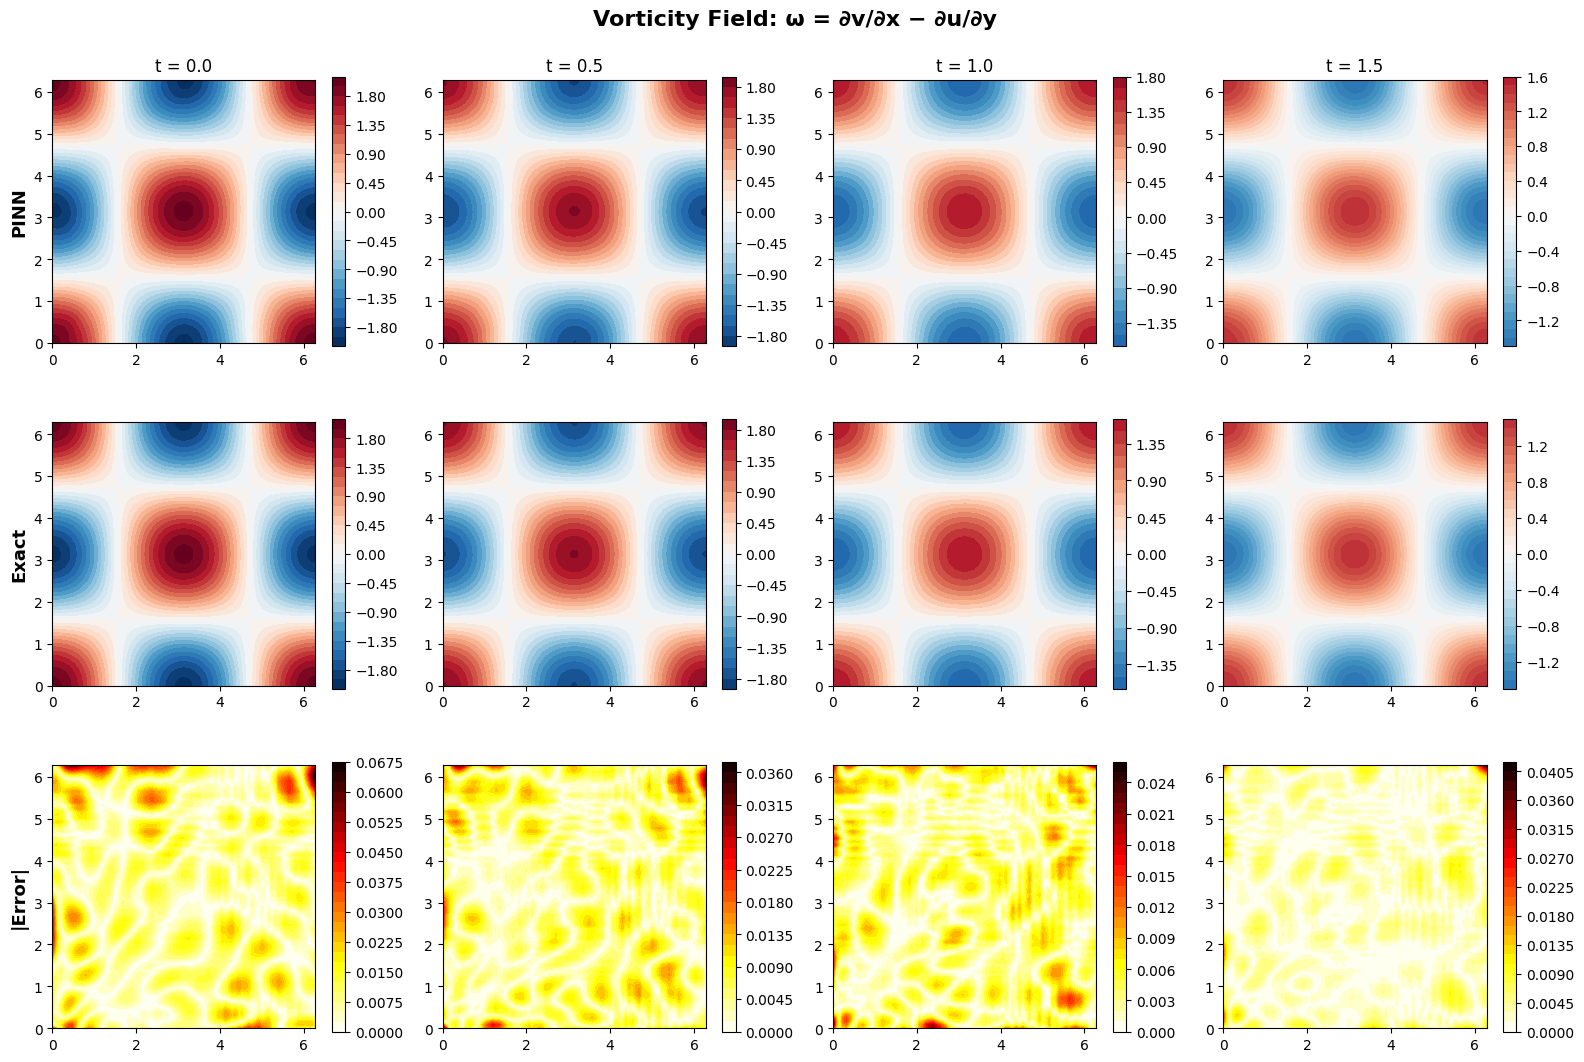

Saved: ns_tgv_vorticity.png

Computing temporal probes...
  Probe: Vortex center (π/2, π/2)
  Probe: Corner (0, 0)
  Probe: Saddle point (π, π/2)


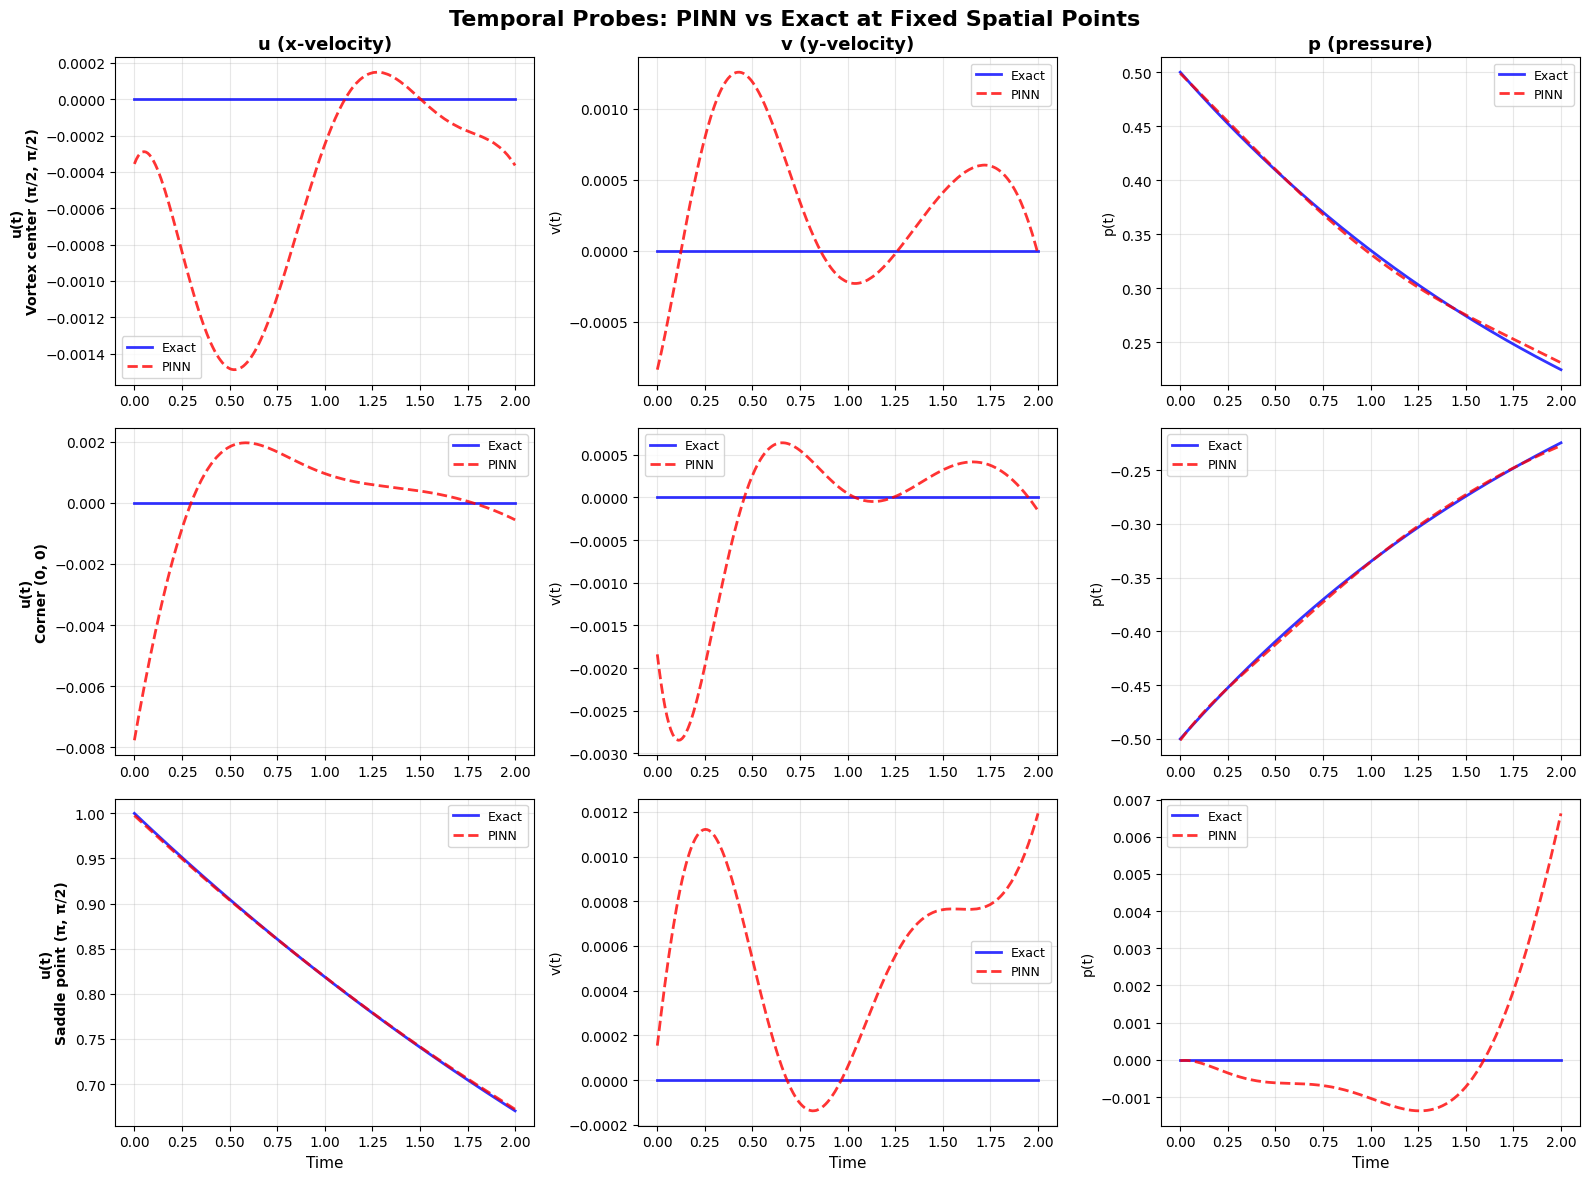

Saved: ns_tgv_temporal_probes.png

Computing line probes...


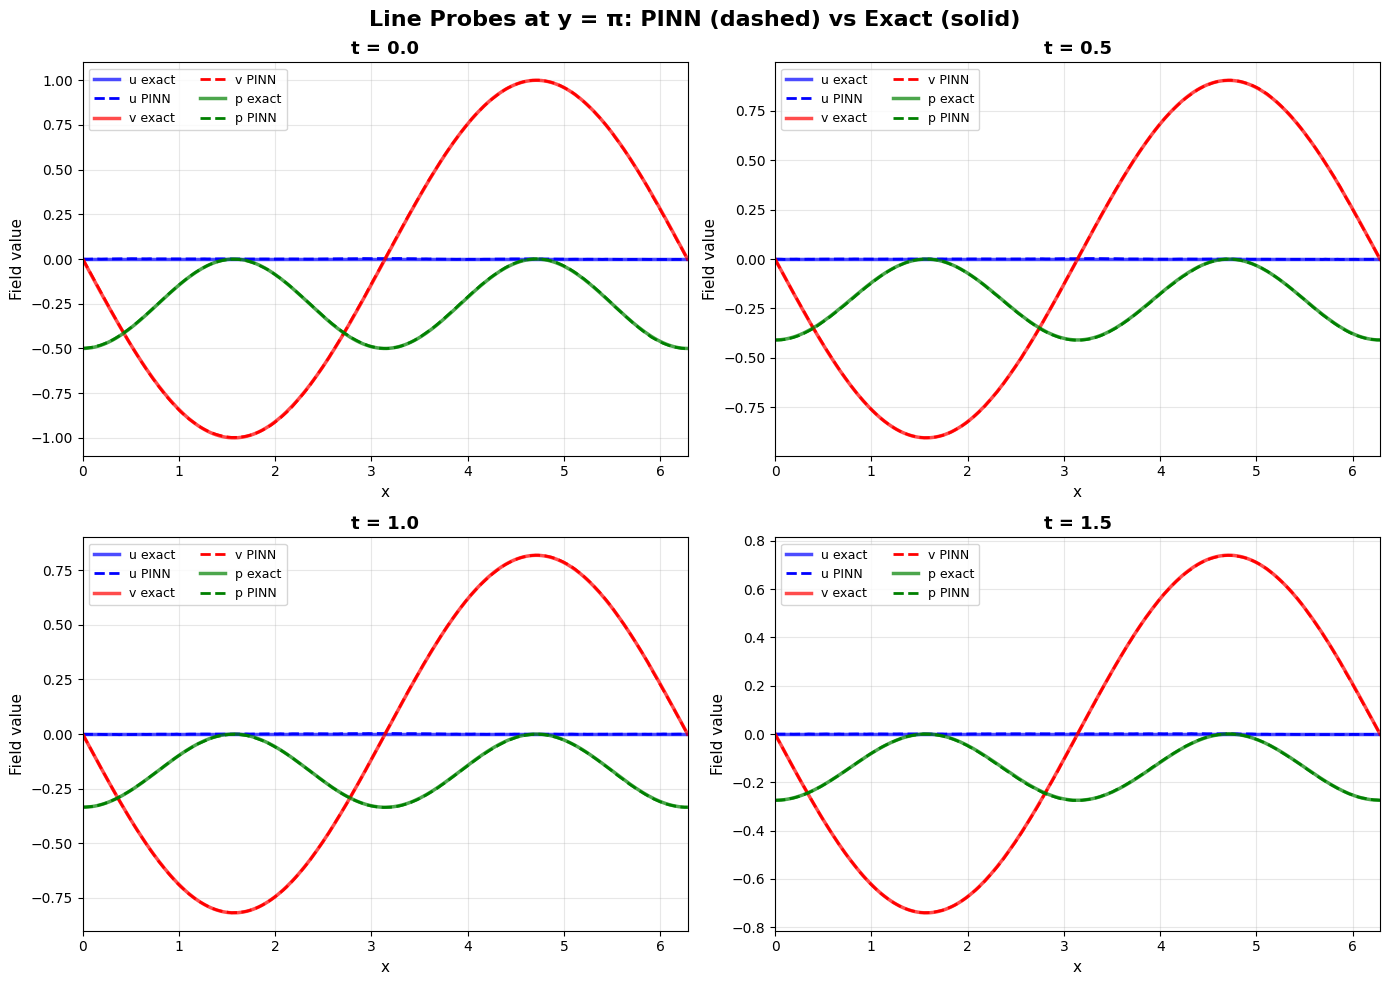

Saved: ns_tgv_line_probes.png

Done! Generated:
  1. ns_tgv_vorticity.png      — Vorticity pred vs exact vs error at 4 time slices
  2. ns_tgv_temporal_probes.png — u, v, p over time at 3 key spatial points
  3. ns_tgv_line_probes.png     — Line cuts at y=π showing all fields vs exact


In [4]:
"""
Professional CFD validation plots for NS TGV PINN
1. Vorticity field (predicted vs exact)
2. Temporal probes at key points
3. Line probes through the domain
Run AFTER training. Assumes: params, network, exact_solution, L, T_final, nu are defined.
"""
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

# ============ 1. VORTICITY FIELD ============
# Vorticity: omega = dv/dx - du/dy
# This is the quantity that tells you WHERE the fluid is spinning.
# For TGV exact vorticity: omega = 2*cos(x)*cos(y)*exp(-2*nu*t)

print("Computing vorticity fields...")

N_test = 80
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)
yy_flat = yy.reshape(-1, 1)
xx_np = np.array(xx)
yy_np = np.array(yy)

def compute_vorticity_single(params, t_val, x_val, y_val):
    """Compute vorticity omega = dv/dx - du/dy at a single point using the PINN."""
    def u_v_p(t, x, y):
        txy = jnp.array([[t, x, y]])
        return network(params, txy)[0]
    
    # Only need dv/dx and du/dy — use jacfwd on specific argnums
    J_x = jax.jacfwd(u_v_p, argnums=1)(t_val, x_val, y_val)  # d(u,v,p)/dx
    J_y = jax.jacfwd(u_v_p, argnums=2)(t_val, x_val, y_val)  # d(u,v,p)/dy
    
    dv_dx = J_x[1]  # v is output index 1, differentiated w.r.t. x
    du_dy = J_y[0]   # u is output index 0, differentiated w.r.t. y
    
    return dv_dx - du_dy

compute_vorticity_batch = jax.vmap(compute_vorticity_single, in_axes=(None, 0, 0, 0))

def exact_vorticity(t, x, y, nu):
    """Exact TGV vorticity: omega = 2*cos(x)*cos(y)*exp(-2*nu*t)"""
    return 2.0 * jnp.cos(x) * jnp.cos(y) * jnp.exp(-2 * nu * t)

# Plot vorticity at multiple time slices
time_slices = [0.0, 0.5, 1.0, 1.5]

fig1, axes1 = plt.subplots(3, len(time_slices), figsize=(16, 11))
fig1.suptitle('Vorticity Field: ω = ∂v/∂x − ∂u/∂y', fontsize=16, fontweight='bold')

# Get global color limits from t=0 exact
omega_max = 2.0  # max of exact vorticity at t=0

for col, t_val in enumerate(time_slices):
    print(f"  Computing vorticity at t = {t_val}...")
    tt_flat = jnp.ones(N_test * N_test) * t_val
    
    # PINN vorticity
    omega_pred = compute_vorticity_batch(params, tt_flat, xx_flat.ravel(), yy_flat.ravel())
    omega_pred_2d = np.array(omega_pred.reshape(N_test, N_test))
    
    # Exact vorticity
    omega_exact_2d = np.array(exact_vorticity(t_val, xx, yy, nu))
    
    # Error
    omega_error_2d = np.abs(omega_pred_2d - omega_exact_2d)
    
    # Predicted
    im0 = axes1[0, col].contourf(xx_np, yy_np, omega_pred_2d, levels=30,
                                   cmap='RdBu_r', vmin=-omega_max, vmax=omega_max)
    axes1[0, col].set_title(f't = {t_val}', fontsize=12)
    axes1[0, col].set_aspect('equal')
    plt.colorbar(im0, ax=axes1[0, col], shrink=0.8)
    
    # Exact
    im1 = axes1[1, col].contourf(xx_np, yy_np, omega_exact_2d, levels=30,
                                   cmap='RdBu_r', vmin=-omega_max, vmax=omega_max)
    axes1[1, col].set_aspect('equal')
    plt.colorbar(im1, ax=axes1[1, col], shrink=0.8)
    
    # Error
    im2 = axes1[2, col].contourf(xx_np, yy_np, omega_error_2d, levels=30, cmap='hot_r')
    axes1[2, col].set_aspect('equal')
    plt.colorbar(im2, ax=axes1[2, col], shrink=0.8)

# Row labels
axes1[0, 0].set_ylabel('PINN', fontsize=13, fontweight='bold')
axes1[1, 0].set_ylabel('Exact', fontsize=13, fontweight='bold')
axes1[2, 0].set_ylabel('|Error|', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('ns_tgv_vorticity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_vorticity.png")


# ============ 2. TEMPORAL PROBES ============
# Track u, v, p at specific points over time.
# This catches temporal drift that spatial snapshots miss.

print("\nComputing temporal probes...")

probe_points = [
    (jnp.pi / 2, jnp.pi / 2, 'Vortex center (π/2, π/2)'),
    (0.0, 0.0, 'Corner (0, 0)'),
    (jnp.pi, jnp.pi / 2, 'Saddle point (π, π/2)'),
]

n_time = 200
t_probe = jnp.linspace(0, T_final, n_time)

fig2, axes2 = plt.subplots(len(probe_points), 3, figsize=(16, 4 * len(probe_points)))
fig2.suptitle('Temporal Probes: PINN vs Exact at Fixed Spatial Points', 
              fontsize=16, fontweight='bold')

for row, (xp, yp, label) in enumerate(probe_points):
    print(f"  Probe: {label}")
    
    u_pred_t = []
    v_pred_t = []
    p_pred_t = []
    u_exact_t = []
    v_exact_t = []
    p_exact_t = []
    
    for tv in t_probe:
        # PINN prediction
        txy = jnp.array([[tv, xp, yp]])
        uvp = network(params, txy)[0]
        u_pred_t.append(float(uvp[0]))
        v_pred_t.append(float(uvp[1]))
        p_pred_t.append(float(uvp[2]))
        
        # Exact
        ue, ve, pe = exact_solution(tv, xp, yp, nu)
        u_exact_t.append(float(ue))
        v_exact_t.append(float(ve))
        p_exact_t.append(float(pe))
    
    t_np = np.array(t_probe)
    
    # u(t)
    axes2[row, 0].plot(t_np, u_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 0].plot(t_np, u_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 0].set_ylabel(f'u(t)\n{label}', fontsize=10, fontweight='bold')
    axes2[row, 0].legend(fontsize=9)
    axes2[row, 0].grid(True, alpha=0.3)
    
    # v(t)
    axes2[row, 1].plot(t_np, v_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 1].plot(t_np, v_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 1].set_ylabel('v(t)', fontsize=10)
    axes2[row, 1].legend(fontsize=9)
    axes2[row, 1].grid(True, alpha=0.3)
    
    # p(t)
    axes2[row, 2].plot(t_np, p_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 2].plot(t_np, p_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 2].set_ylabel('p(t)', fontsize=10)
    axes2[row, 2].legend(fontsize=9)
    axes2[row, 2].grid(True, alpha=0.3)

# Column titles
axes2[0, 0].set_title('u (x-velocity)', fontsize=13, fontweight='bold')
axes2[0, 1].set_title('v (y-velocity)', fontsize=13, fontweight='bold')
axes2[0, 2].set_title('p (pressure)', fontsize=13, fontweight='bold')

# x labels on bottom row only
for col in range(3):
    axes2[-1, col].set_xlabel('Time', fontsize=11)

plt.tight_layout()
plt.savefig('ns_tgv_temporal_probes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_temporal_probes.png")


# ============ 3. LINE PROBES ============
# Cut through the domain at fixed y, plot u(x) at multiple times.
# This reveals phase errors and amplitude drift that contour plots hide.

print("\nComputing line probes...")

N_line = 200
x_line = jnp.linspace(0, L, N_line)
y_fixed = jnp.pi  # Cut through middle of domain

fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle(f'Line Probes at y = π: PINN (dashed) vs Exact (solid)', 
              fontsize=16, fontweight='bold')

t_line_vals = [0.0, 0.5, 1.0, 1.5]

for idx, t_val in enumerate(t_line_vals):
    ax = axes3.flat[idx]
    
    # PINN predictions along the line
    txy_line = jnp.stack([
        jnp.ones(N_line) * t_val,
        x_line,
        jnp.ones(N_line) * y_fixed
    ], axis=1)  # (N_line, 3)
    
    uvp_line = network(params, txy_line)
    u_line_pred = np.array(uvp_line[:, 0])
    v_line_pred = np.array(uvp_line[:, 1])
    p_line_pred = np.array(uvp_line[:, 2])
    
    # Exact along the line
    u_ex = np.array(-jnp.cos(x_line) * jnp.sin(y_fixed) * jnp.exp(-2 * nu * t_val))
    v_ex = np.array(jnp.sin(x_line) * jnp.cos(y_fixed) * jnp.exp(-2 * nu * t_val))
    p_ex = np.array(-0.25 * (jnp.cos(2 * x_line) + jnp.cos(2 * y_fixed)) * jnp.exp(-4 * nu * t_val))
    
    x_np = np.array(x_line)
    
    ax.plot(x_np, u_ex, 'b-', linewidth=2.5, label='u exact', alpha=0.7)
    ax.plot(x_np, u_line_pred, 'b--', linewidth=2, label='u PINN')
    
    ax.plot(x_np, v_ex, 'r-', linewidth=2.5, label='v exact', alpha=0.7)
    ax.plot(x_np, v_line_pred, 'r--', linewidth=2, label='v PINN')
    
    ax.plot(x_np, p_ex, 'g-', linewidth=2.5, label='p exact', alpha=0.7)
    ax.plot(x_np, p_line_pred, 'g--', linewidth=2, label='p PINN')
    
    ax.set_title(f't = {t_val}', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('Field value', fontsize=11)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, float(L))

plt.tight_layout()
plt.savefig('ns_tgv_line_probes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_line_probes.png")


print("\nDone! Generated:")
print("  1. ns_tgv_vorticity.png      — Vorticity pred vs exact vs error at 4 time slices")
print("  2. ns_tgv_temporal_probes.png — u, v, p over time at 3 key spatial points")
print("  3. ns_tgv_line_probes.png     — Line cuts at y=π showing all fields vs exact")